In [2]:
# =========================================================
# 1. IMPORT LIBRARY
# =========================================================

import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Model Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Evaluasi
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Simpan model
import joblib

# Ignore warning
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('Sales - Marketing customer dataset.csv')

# Menampilkan 5 data pertama
print(df.head())

   customer_id  gender   age  country     city          signup_date  \
0        10001    Male  52.0    India   Berlin  2022-05-10 00:00:00   
1        10002     NaN  35.0  Germany   Mumbai  2024-06-16 00:00:00   
2        10003  Female  27.0  Germany   London  2023-08-23 00:00:00   
3        10004  Female  36.0    India   Mumbai  2024-01-28 00:00:00   
4        10005    Male  29.0      USA  Hamburg  2023-07-21 00:00:00   

    last_purchase_date acquisition_channel device_type subscription_type  ...  \
0  2024-12-31 00:00:00               Email      Tablet            Annual  ...   
1  2024-05-07 00:00:00             Organic     Desktop           Monthly  ...   
2  2024-04-28 00:00:00               Email      Mobile            Annual  ...   
3  2023-05-20 00:00:00        Facebook Ads      Tablet            Annual  ...   
4  2024-04-07 00:00:00            Referral      Mobile           Monthly  ...   

   support_tickets  refund_requested  delivery_delay_days  payment_method  \
0        

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           150

In [5]:
print(df.describe())

        customer_id           age  is_premium_user  total_visits  \
count  15000.000000  13800.000000     15000.000000  15000.000000   
mean   17500.500000     35.203913         0.304467     15.000933   
std     4330.271354     10.334384         0.460197      3.892704   
min    10001.000000     -4.000000         0.000000      3.000000   
25%    13750.750000     28.000000         0.000000     12.000000   
50%    17500.500000     35.000000         0.000000     15.000000   
75%    21250.250000     42.000000         1.000000     18.000000   
max    25000.000000     95.000000         1.000000     31.000000   

       avg_session_time  pages_per_session  email_open_rate  email_click_rate  \
count      15000.000000       15000.000000     15000.000000      15000.000000   
mean           8.020805           4.002901         0.496278          0.251231   
std            2.991499           1.479846         0.290108          0.144689   
min            0.006095           0.007845         0.000000    

In [6]:
missing = df.isnull().sum()

missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Value': missing,
    'Percentage': missing_percent
})

print("\nMISSING VALUE")
display(missing_df)



MISSING VALUE


,Missing Value,Percentage
customer_id,0,0.000000
gender,738,4.920000
age,1200,8.000000
country,0,0.000000
city,0,0.000000
signup_date,0,0.000000
last_purchase_date,0,0.000000
acquisition_channel,0,0.000000
device_type,0,0.000000
subscription_type,0,0.000000


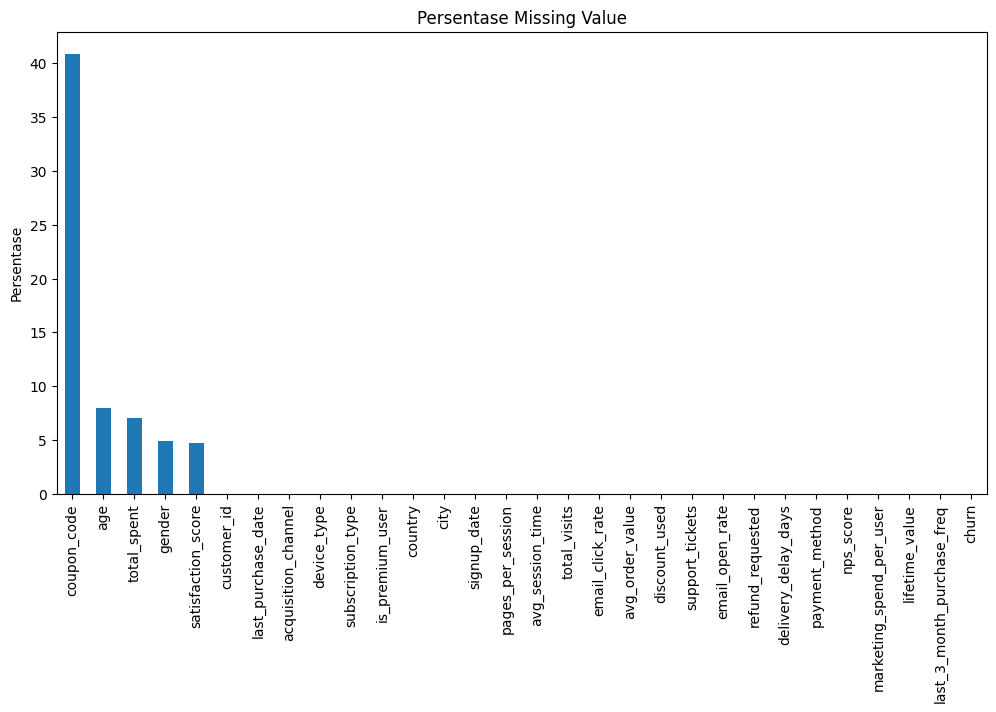

In [7]:
# =========================================================
# VISUALISASI MISSING VALUE
# =========================================================

plt.figure(figsize=(12,6))

missing_percent.sort_values(
    ascending=False
).plot(
    kind='bar'
)

plt.title('Persentase Missing Value')
plt.ylabel('Persentase')

plt.show()

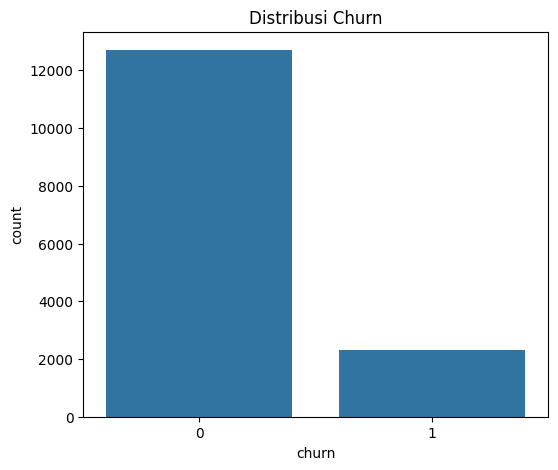

churn
0    12702
1     2298
Name: count, dtype: int64


In [8]:
# =========================================================
# DISTRIBUSI CHURN
# =========================================================

plt.figure(figsize=(6,5))

sns.countplot(
    x='churn',
    data=df
)

plt.title('Distribusi Churn')

plt.show()

print(df['churn'].value_counts())


# Insight Distribusi Churn
- Kelas tidak churn (0) mendominasi dataset dengan jumlah sekitar 12.700 pelanggan.
- Kelas churn (1) hanya berjumlah sekitar 2.300 pelanggan.
- Perbandingan kedua kelas menunjukkan distribusi yang tidak seimbang (imbalanced dataset), dimana pelanggan tidak churn jauh lebih banyak dibandingkan pelanggan churn.

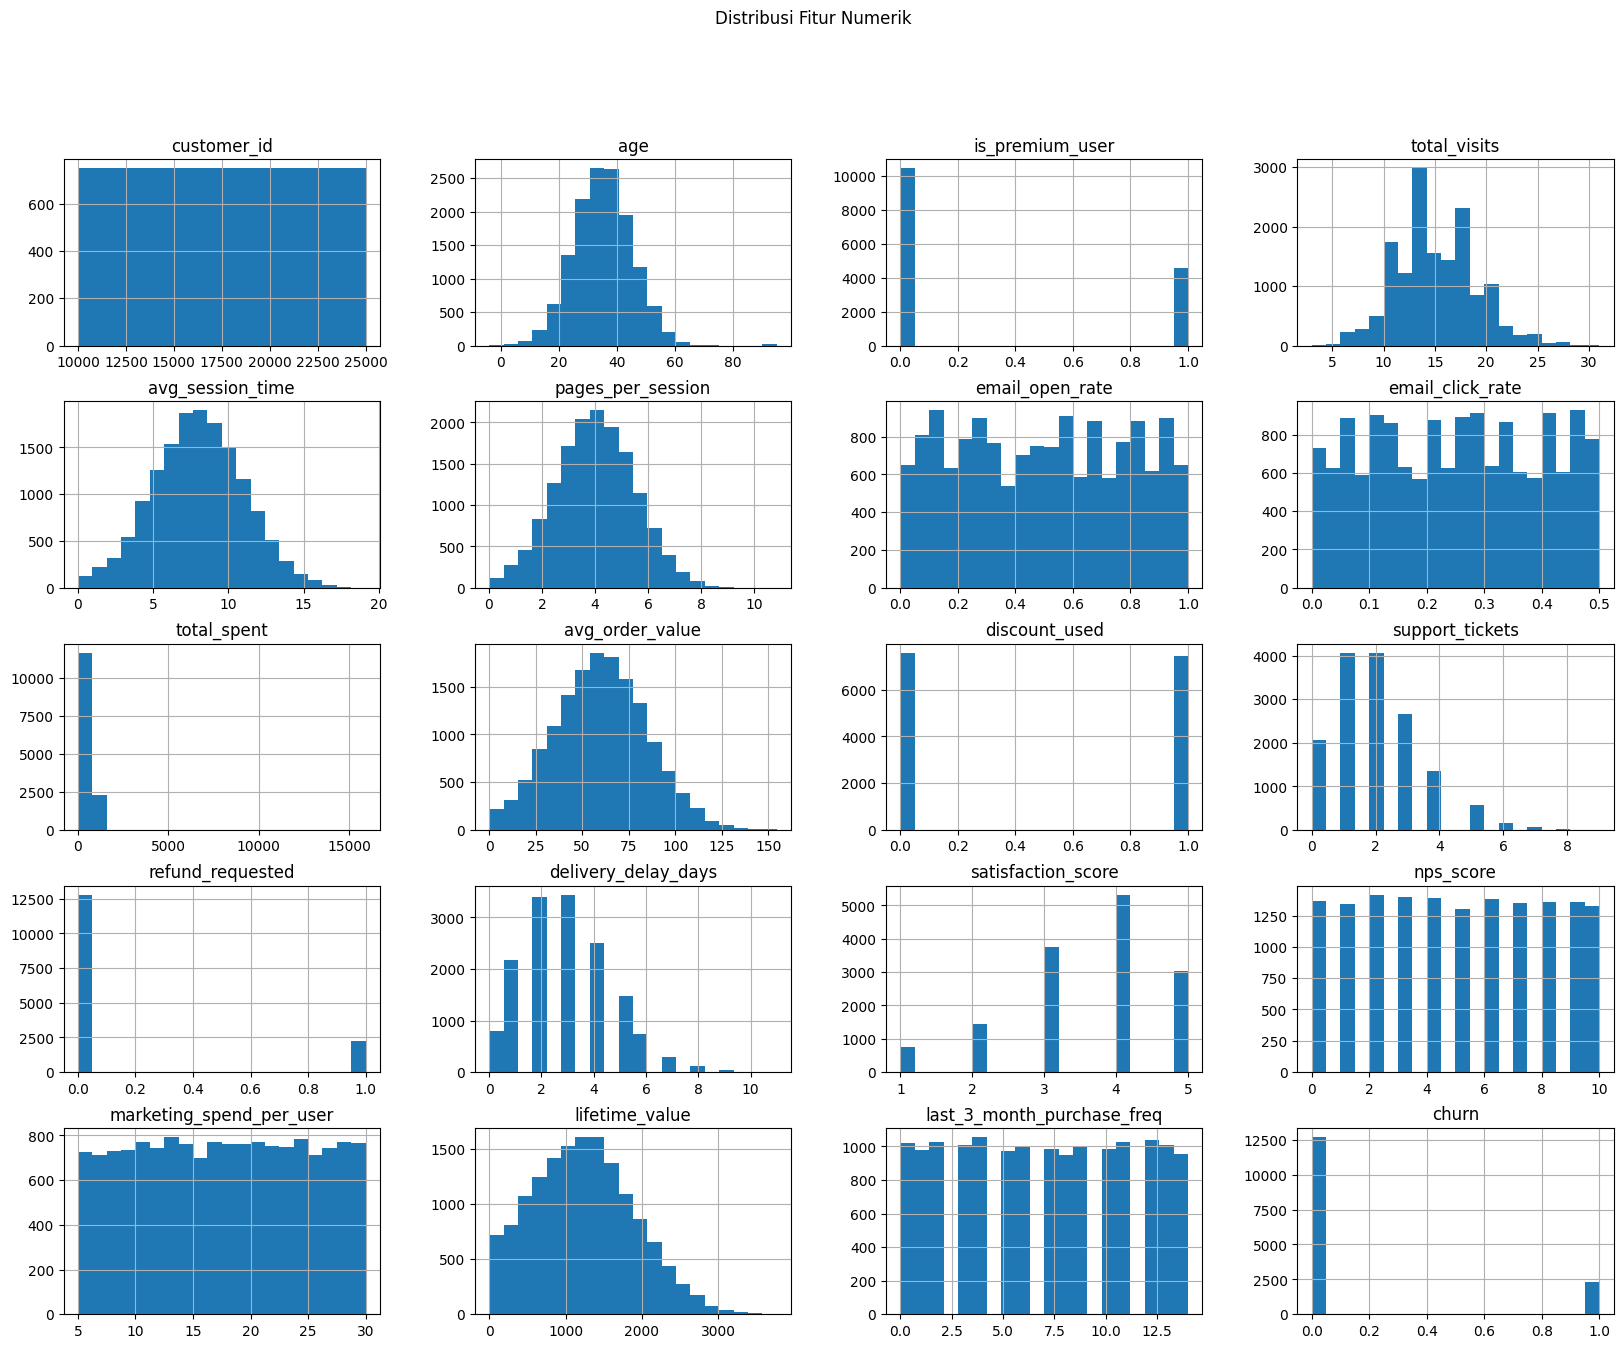

In [9]:
# =========================================================
# DISTRIBUSI FITUR NUMERIK
# =========================================================

df.hist(
    figsize=(20,15),
    bins=20
)

plt.suptitle('Distribusi Fitur Numerik')

plt.show()

1. Customer ID

Insight: Hanya berfungsi sebagai identitas pelanggan dan tidak menunjukkan pola tertentu.
Kesimpulan: Dihapus pada tahap preprocessing karena tidak berpengaruh terhadap churn.

2. Age

Insight: Mayoritas pelanggan berusia 25–45 tahun.
Kesimpulan: Pelanggan didominasi usia produktif.

3. Is Premium User

Insight: Pengguna non-premium lebih banyak dibanding premium.
Kesimpulan: Status premium berpotensi memengaruhi churn.

4. Total Visits

Insight: Sebagian besar pelanggan memiliki 10–20 kunjungan.
Kesimpulan: Pelanggan cukup aktif menggunakan platform.

5. Avg Session Time

Insight: Mayoritas durasi sesi berada pada rentang 5–10 menit.
Kesimpulan: Tingkat keterlibatan pelanggan cukup baik.

6. Pages Per Session

Insight: Sebagian besar pelanggan membuka 2–6 halaman per sesi.
Kesimpulan: Pelanggan aktif mengeksplorasi platform.

7. Email Open Rate

Insight: Distribusi cukup merata.
Kesimpulan: Tingkat pembukaan email bervariasi antar pelanggan.

8. Email Click Rate

Insight: Distribusi relatif merata.
Kesimpulan: Respons pelanggan terhadap email promosi cukup beragam.

9. Total Spent

Insight: Sebagian besar pelanggan memiliki pengeluaran rendah hingga sedang, dengan sedikit pelanggan berpengeluaran sangat tinggi.
Kesimpulan: Terdapat pelanggan bernilai tinggi yang berkontribusi besar terhadap pendapatan.

10. Avg Order Value

Insight: Distribusi mendekati normal.
Kesimpulan: Nilai transaksi pelanggan relatif stabil.

11. Discount Used

Insight: Pengguna diskon dan non-diskon relatif seimbang.
Kesimpulan: Diskon berpotensi memengaruhi perilaku pembelian.

12. Support Tickets

Insight: Mayoritas pelanggan hanya memiliki 0–3 tiket dukungan.
Kesimpulan: Sebagian besar pelanggan jarang mengalami masalah layanan.

13. Refund Requested

Insight: Sebagian besar pelanggan tidak pernah melakukan refund.
Kesimpulan: Refund bukan kejadian yang umum terjadi.

14. Delivery Delay Days

Insight: Mayoritas keterlambatan pengiriman berada pada rentang 1–5 hari.
Kesimpulan: Pengiriman relatif tepat waktu.

15. Satisfaction Score

Insight: Didominasi skor 3–5, terutama skor 4.
Kesimpulan: Tingkat kepuasan pelanggan cukup baik.

16. NPS Score

Insight: Distribusi skor relatif merata.
Kesimpulan: Tingkat loyalitas pelanggan cukup beragam.

17. Marketing Spend Per User

Insight: Distribusi relatif merata pada seluruh rentang nilai.
Kesimpulan: Biaya pemasaran per pelanggan cukup konsisten.

18. Lifetime Value

Insight: Sebagian besar pelanggan memiliki lifetime value pada rentang menengah.
Kesimpulan: Kontribusi nilai pelanggan relatif stabil.

19. Last 3 Month Purchase Frequency

Insight: Frekuensi pembelian tersebar cukup merata.
Kesimpulan: Aktivitas pembelian pelanggan beragam.

20. Churn

Insight: Jumlah pelanggan tidak churn jauh lebih banyak dibanding churn.
Kesimpulan: Dataset memiliki kondisi imbalanced class yang perlu diperhatikan pada tahap pemodelan.

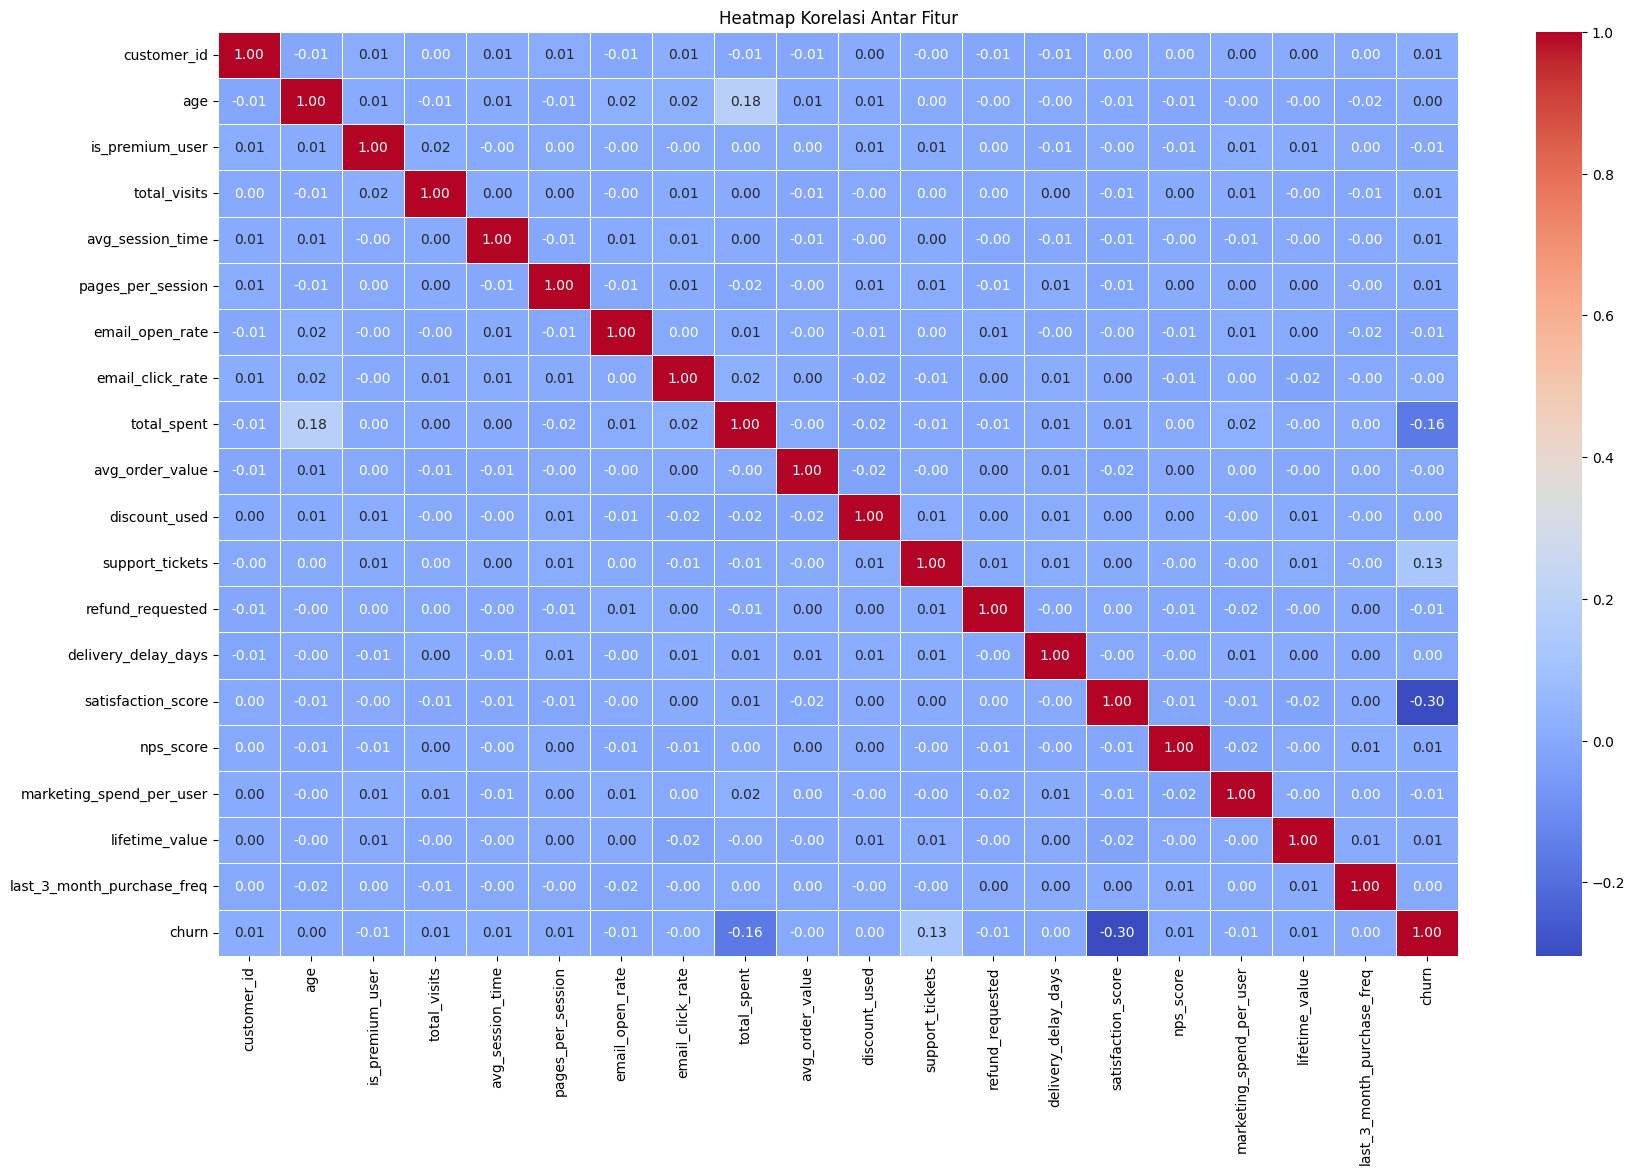

In [10]:
plt.figure(figsize=(20,12))

numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Heatmap Korelasi Antar Fitur')

plt.show()

# Insight Heatmap Korelasi Antar Fitur
Secara umum, sebagian besar fitur memiliki nilai korelasi yang rendah (mendekati 0), sehingga tidak terdapat hubungan linear yang kuat antar fitur.
Satisfaction Score memiliki korelasi negatif terbesar terhadap Churn sebesar -0.30, yang menunjukkan bahwa semakin tinggi tingkat kepuasan pelanggan, semakin kecil kemungkinan pelanggan melakukan churn.
Total Spent memiliki korelasi negatif terhadap Churn sebesar -0.16, yang mengindikasikan bahwa pelanggan dengan total pengeluaran lebih tinggi cenderung lebih loyal.
Support Tickets memiliki korelasi positif terhadap Churn sebesar 0.13, yang menunjukkan bahwa semakin banyak keluhan atau tiket dukungan yang dibuat pelanggan, semakin besar kemungkinan pelanggan melakukan churn.
Korelasi antara Age dan Total Spent sebesar 0.18, menunjukkan hubungan positif yang lemah dimana pelanggan yang lebih dewasa cenderung memiliki pengeluaran sedikit lebih tinggi.
Tidak ditemukan korelasi yang sangat tinggi (> 0.8) antar fitur, sehingga tidak terdapat indikasi multikolinearitas yang signifikan.

In [11]:
# =========================================================
# KORELASI TERHADAP CHURN
# =========================================================

corr_churn = numeric_df.corr()['churn'].sort_values(
    ascending=False
)

print("\nKORELASI TERHADAP CHURN")
display(corr_churn)


KORELASI TERHADAP CHURN


,churn
churn,1.000000
support_tickets,0.127910
total_visits,0.013212
customer_id,0.012208
avg_session_time,0.012198
lifetime_value,0.006250
pages_per_session,0.005871
nps_score,0.005749
age,0.004506
delivery_delay_days,0.001603


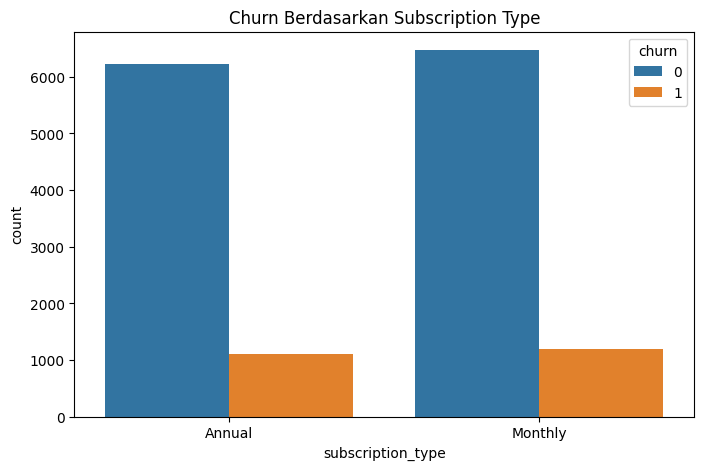

In [12]:
# =========================================================
# ANALISIS CHURN BERDASARKAN SUBSCRIPTION TYPE
# =========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='subscription_type',
    hue='churn',
    data=df
)

plt.title('Churn Berdasarkan Subscription Type')

plt.show()

# Insight Churn Berdasarkan Subscription Type
Baik pelanggan Annual maupun Monthly didominasi oleh pelanggan yang tidak churn (0).
Jumlah pelanggan Monthly sedikit lebih banyak dibandingkan pelanggan Annual.
Jumlah pelanggan yang melakukan churn (1) pada paket Monthly juga sedikit lebih tinggi dibandingkan paket Annual.
Namun, perbedaan antara kedua jenis langganan tidak terlalu signifikan.

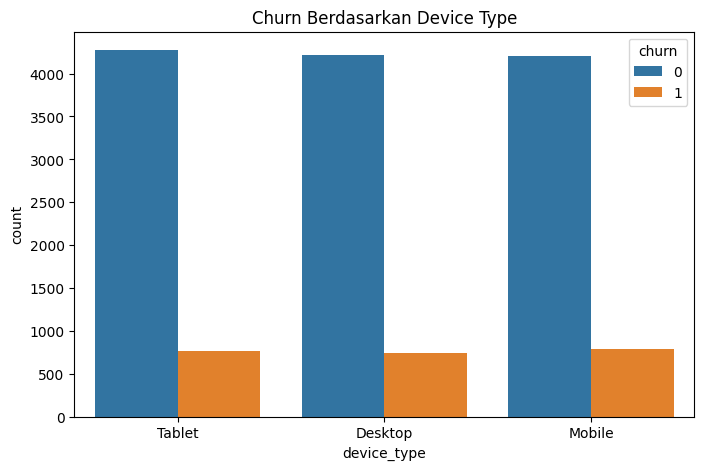

In [13]:
# =========================================================
# NALISIS CHURN BERDASARKAN DEVICE TYPE
# =========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='device_type',
    hue='churn',
    data=df
)

plt.title('Churn Berdasarkan Device Type')

plt.show()

# Insight Churn Berdasarkan Device Type
Jumlah pelanggan pada perangkat Mobile, Desktop, dan Tablet relatif seimbang.
Pada ketiga jenis perangkat, jumlah pelanggan yang tidak churn (0) jauh lebih banyak dibandingkan pelanggan yang churn (1).
Pelanggan Mobile memiliki jumlah churn sedikit lebih tinggi dibandingkan Desktop dan Tablet.
Namun, perbedaan jumlah churn antar perangkat tidak terlalu signifikan.

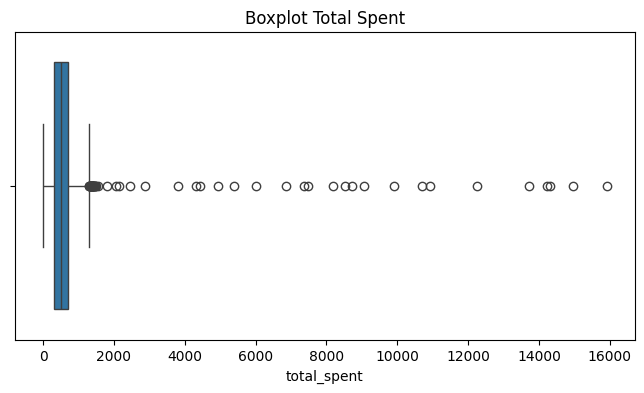

In [14]:
# =========================================================
# BOXPLOT OUTLIER
# =========================================================

plt.figure(figsize=(8,4))

sns.boxplot(
    x=df['total_spent']
)

plt.title('Boxplot Total Spent')

plt.show()

# Insight Boxplot Total Spent
Sebagian besar pelanggan memiliki nilai total_spent pada rentang yang relatif rendah hingga menengah.
Terlihat banyak outlier di sisi kanan boxplot dengan nilai pengeluaran yang sangat tinggi.
Distribusi data cenderung right-skewed (miring ke kanan), yang menunjukkan adanya beberapa pelanggan dengan total pengeluaran jauh di atas rata-rata.


# DIRECT MODELING (3 MODEL)
# TANPA PREPROCESSING


In [15]:
# =========================================================
# COPY DATASET
# =========================================================

df_direct = df.copy()

In [16]:
# =========================================================
# HANDLE MISSING VALUE
# =========================================================

for col in df_direct.columns:

    if df_direct[col].dtype == 'object':

        df_direct[col].fillna(
            df_direct[col].mode()[0],
            inplace=True
        )

    else:

        df_direct[col].fillna(
            df_direct[col].median(),
            inplace=True
        )

In [17]:
# =========================================================
# ENCODING DIRECT
# =========================================================

le = LabelEncoder()

for col in df_direct.select_dtypes(include='object').columns:

    df_direct[col] = le.fit_transform(
        df_direct[col].astype(str)
    )

In [18]:
# =========================================================
# MENENTUKAN X DAN Y
# =========================================================

X_direct = df_direct.drop('churn', axis=1)

y_direct = df_direct['churn']

In [19]:
# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train_direct, X_test_direct, y_train_direct, y_test_direct = train_test_split(
    X_direct,
    y_direct,
    test_size=0.2,
    random_state=42
)

DIRECT MODELING - LOGISTIC REGRESSION
Accuracy : 0.853
Precision : 0.6153846153846154
Recall : 0.018018018018018018
F1 Score : 0.0350109409190372


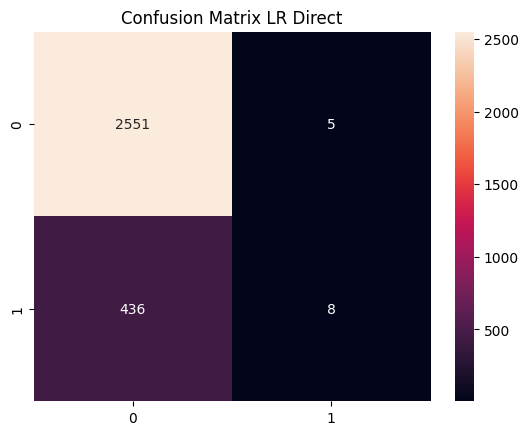

In [20]:
# =========================================================
# DIRECT MODELING - LOGISTIC REGRESSION
# =========================================================

lr_direct = LogisticRegression()

lr_direct.fit(X_train_direct, y_train_direct)

y_pred_lr_direct = lr_direct.predict(X_test_direct)

print("DIRECT MODELING - LOGISTIC REGRESSION")

print("Accuracy :",
      accuracy_score(y_test_direct, y_pred_lr_direct))

print("Precision :",
      precision_score(y_test_direct, y_pred_lr_direct))

print("Recall :",
      recall_score(y_test_direct, y_pred_lr_direct))

print("F1 Score :",
      f1_score(y_test_direct, y_pred_lr_direct))

cm = confusion_matrix(y_test_direct, y_pred_lr_direct)

sns.heatmap(cm, annot=True, fmt='d')

plt.title('Confusion Matrix LR Direct')

plt.show()

# Interpretasi
2551 data berhasil diprediksi dengan benar sebagai tidak churn (True Negative).
8 data berhasil diprediksi dengan benar sebagai churn (True Positive).
5 data diprediksi churn padahal sebenarnya tidak churn (False Positive).
436 data diprediksi tidak churn padahal sebenarnya churn (False Negative).

DIRECT MODELING - RANDOM FOREST
Accuracy : 0.855
Precision : 0.5154639175257731
Recall : 0.33783783783783783
F1 Score : 0.40816326530612246


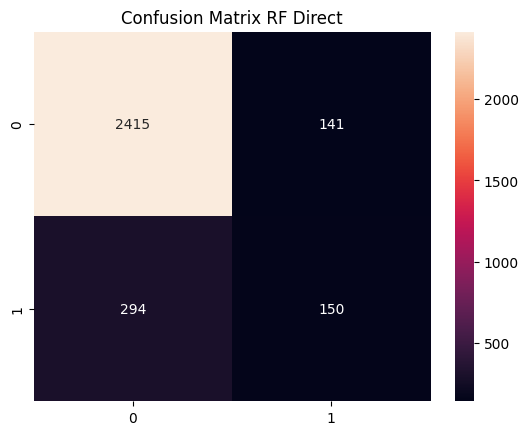

In [21]:
# =========================================================
# DIRECT MODELING - RANDOM FOREST
# =========================================================

rf_direct = RandomForestClassifier()

rf_direct.fit(X_train_direct, y_train_direct)

y_pred_rf_direct = rf_direct.predict(X_test_direct)

print("DIRECT MODELING - RANDOM FOREST")

print("Accuracy :",
      accuracy_score(y_test_direct, y_pred_rf_direct))

print("Precision :",
      precision_score(y_test_direct, y_pred_rf_direct))

print("Recall :",
      recall_score(y_test_direct, y_pred_rf_direct))

print("F1 Score :",
      f1_score(y_test_direct, y_pred_rf_direct))

cm = confusion_matrix(y_test_direct, y_pred_rf_direct)

sns.heatmap(cm, annot=True, fmt='d')

plt.title('Confusion Matrix RF Direct')

plt.show()


# Interpretasi
2415 data berhasil diprediksi dengan benar sebagai tidak churn (True Negative).
150 data berhasil diprediksi dengan benar sebagai churn (True Positive).
141 data diprediksi churn padahal sebenarnya tidak churn (False Positive).
294 data diprediksi tidak churn padahal sebenarnya churn (False Negative).

DIRECT MODELING - VOTING CLASSIFIER
Accuracy : 0.853
Precision : 1.0
Recall : 0.006756756756756757
F1 Score : 0.013422818791946308


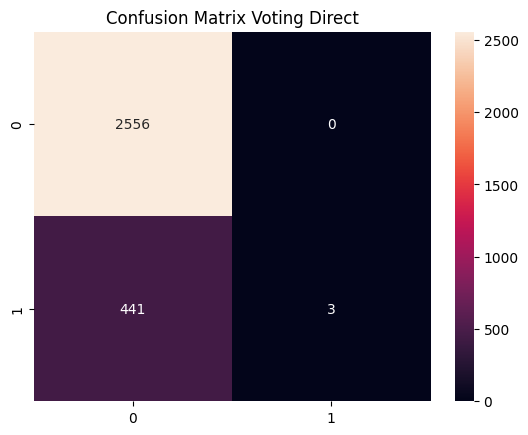

In [22]:
# =========================================================
# DIRECT MODELING - VOTING CLASSIFIER
# =========================================================

voting_direct = VotingClassifier(

    estimators=[
        ('lr', LogisticRegression()),
        ('knn', KNeighborsClassifier()),
        ('svm', SVC(probability=True))
    ],

    voting='soft'
)

voting_direct.fit(X_train_direct, y_train_direct)

y_pred_voting_direct = voting_direct.predict(X_test_direct)

print("DIRECT MODELING - VOTING CLASSIFIER")

print("Accuracy :",
      accuracy_score(y_test_direct, y_pred_voting_direct))

print("Precision :",
      precision_score(y_test_direct, y_pred_voting_direct))

print("Recall :",
      recall_score(y_test_direct, y_pred_voting_direct))

print("F1 Score :",
      f1_score(y_test_direct, y_pred_voting_direct))

cm = confusion_matrix(y_test_direct, y_pred_voting_direct)

sns.heatmap(cm, annot=True, fmt='d')

plt.title('Confusion Matrix Voting Direct')

plt.show()

# Interpretasi
2556 data berhasil diprediksi dengan benar sebagai tidak churn (True Negative).
3 data berhasil diprediksi dengan benar sebagai churn (True Positive).
0 data diprediksi churn padahal sebenarnya tidak churn (False Positive).
441 data diprediksi tidak churn padahal sebenarnya churn (False Negative).

# PREPROCESSING MODELING (3 MODEL)

In [23]:
# =========================================================
# COPY DATASET
# =========================================================

df_pre = df.copy()

In [24]:
# =========================================================
# DROP DUPLICATE
# =========================================================

df_pre.drop_duplicates(inplace=True)


In [25]:
# =========================================================
# HANDLE MISSING VALUE
# =========================================================

df_pre['gender'].fillna(
    df_pre['gender'].mode()[0],
    inplace=True
)

df_pre['age'].fillna(
    df_pre['age'].median(),
    inplace=True
)

df_pre['total_spent'].fillna(
    df_pre['total_spent'].median(),
    inplace=True
)

df_pre['satisfaction_score'].fillna(
    df_pre['satisfaction_score'].median(),
    inplace=True
)


In [26]:
# =========================================================
# DROP KOLOM TIDAK PENTING
# =========================================================

df_pre.drop(
    'coupon_code',
    axis=1,
    inplace=True
)

df_pre.drop(
    'customer_id',
    axis=1,
    inplace=True
)

In [27]:
# =========================================================
# ENCODING
# =========================================================

le = LabelEncoder()

for col in df_pre.select_dtypes(include='object').columns:

    df_pre[col] = le.fit_transform(
        df_pre[col].astype(str)
    )

print("Data setelah encoding")
display(df_pre.head())

Data setelah encoding


,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,is_premium_user,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,1,52.0,2,0,129,730,0,2,0,1,...,0,0,3,4,3.0,10,27.56,915.310827,14,0
1,1,35.0,1,5,897,492,3,0,1,0,...,5,0,3,0,3.0,7,15.15,2079.960938,11,0
2,0,27.0,1,4,599,483,0,1,0,1,...,1,0,2,4,5.0,6,13.51,1379.150885,9,0
3,0,36.0,2,5,757,139,1,2,0,1,...,0,0,2,2,4.0,6,25.65,774.652684,7,0
4,1,29.0,4,3,566,462,4,1,1,0,...,2,1,4,0,3.0,1,12.39,87.680409,11,0


In [28]:
# =========================================================
# MENENTUKAN X DAN Y
# =========================================================

X_pre = df_pre.drop('churn', axis=1)

y_pre = df_pre['churn']

In [29]:
# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train_pre, X_test_pre, y_train_pre, y_test_pre = train_test_split(
    X_pre,
    y_pre,
    test_size=0.2,
    random_state=42
)

In [30]:
# =========================================================
# SCALING
# =========================================================

scaler = StandardScaler()

X_train_pre = scaler.fit_transform(X_train_pre)

X_test_pre = scaler.transform(X_test_pre)


PREPROCESSING MODELING - LOGISTIC REGRESSION
Accuracy : 0.8506666666666667
Precision : 0.4875
Recall : 0.17567567567567569
F1 Score : 0.2582781456953642


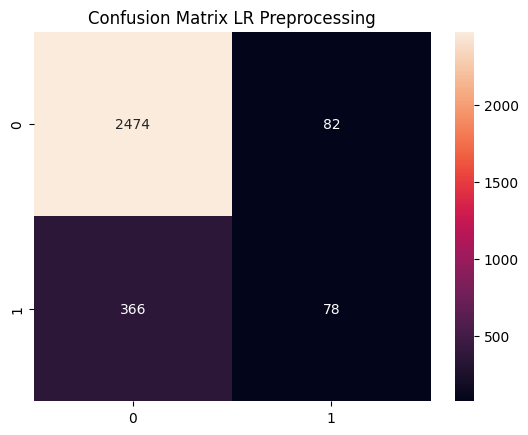

In [31]:
# =========================================================
# PREPROCESSING MODELING - LOGISTIC REGRESSION
# =========================================================

lr_pre = LogisticRegression()

lr_pre.fit(X_train_pre, y_train_pre)

y_pred_lr_pre = lr_pre.predict(X_test_pre)

print("PREPROCESSING MODELING - LOGISTIC REGRESSION")

print("Accuracy :",
      accuracy_score(y_test_pre, y_pred_lr_pre))

print("Precision :",
      precision_score(y_test_pre, y_pred_lr_pre))

print("Recall :",
      recall_score(y_test_pre, y_pred_lr_pre))

print("F1 Score :",
      f1_score(y_test_pre, y_pred_lr_pre))

cm = confusion_matrix(y_test_pre, y_pred_lr_pre)

sns.heatmap(cm, annot=True, fmt='d')

plt.title('Confusion Matrix LR Preprocessing')

plt.show()


# Interpretasi
2474 data berhasil diprediksi dengan benar sebagai tidak churn (True Negative).
78 data berhasil diprediksi dengan benar sebagai churn (True Positive).
82 data diprediksi churn padahal sebenarnya tidak churn (False Positive).
366 data diprediksi tidak churn padahal sebenarnya churn (False Negative).

PREPROCESSING MODELING - RANDOM FOREST
Accuracy : 0.848
Precision : 0.48089171974522293
Recall : 0.3400900900900901
F1 Score : 0.39841688654353563


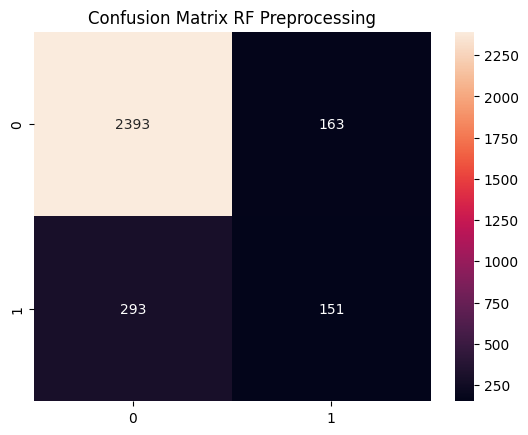

In [32]:
# =========================================================
# PREPROCESSING MODELING - RANDOM FOREST
# =========================================================

rf_pre = RandomForestClassifier()

rf_pre.fit(X_train_pre, y_train_pre)

y_pred_rf_pre = rf_pre.predict(X_test_pre)

print("PREPROCESSING MODELING - RANDOM FOREST")

print("Accuracy :",
      accuracy_score(y_test_pre, y_pred_rf_pre))

print("Precision :",
      precision_score(y_test_pre, y_pred_rf_pre))

print("Recall :",
      recall_score(y_test_pre, y_pred_rf_pre))

print("F1 Score :",
      f1_score(y_test_pre, y_pred_rf_pre))

cm = confusion_matrix(y_test_pre, y_pred_rf_pre)

sns.heatmap(cm, annot=True, fmt='d')

plt.title('Confusion Matrix RF Preprocessing')

plt.show()

# Interpretasi
2393 data berhasil diprediksi dengan benar sebagai tidak churn (True Negative).
151 data berhasil diprediksi dengan benar sebagai churn (True Positive).
163 data diprediksi churn padahal sebenarnya tidak churn (False Positive).
293 data diprediksi tidak churn padahal sebenarnya churn (False Negative).

PREPROCESSING MODELING - VOTING CLASSIFIER
Accuracy : 0.8486666666666667
Precision : 0.4519230769230769
Recall : 0.10585585585585586
F1 Score : 0.17153284671532848


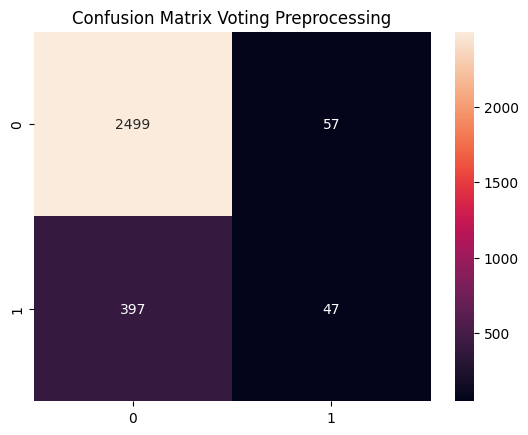

In [33]:
# =========================================================
# PREPROCESSING MODELING - VOTING CLASSIFIER
# =========================================================

voting_pre = VotingClassifier(

    estimators=[
        ('lr', LogisticRegression()),
        ('knn', KNeighborsClassifier()),
        ('svm', SVC(probability=True))
    ],

    voting='soft'
)

voting_pre.fit(X_train_pre, y_train_pre)

y_pred_voting_pre = voting_pre.predict(X_test_pre)

print("PREPROCESSING MODELING - VOTING CLASSIFIER")

print("Accuracy :",
      accuracy_score(y_test_pre, y_pred_voting_pre))

print("Precision :",
      precision_score(y_test_pre, y_pred_voting_pre))

print("Recall :",
      recall_score(y_test_pre, y_pred_voting_pre))

print("F1 Score :",
      f1_score(y_test_pre, y_pred_voting_pre))

cm = confusion_matrix(y_test_pre, y_pred_voting_pre)

sns.heatmap(cm, annot=True, fmt='d')

plt.title('Confusion Matrix Voting Preprocessing')

plt.show()

# Interpretasi
2499 data berhasil diprediksi dengan benar sebagai tidak churn (True Negative).
47 data berhasil diprediksi dengan benar sebagai churn (True Positive).
57 data diprediksi churn padahal sebenarnya tidak churn (False Positive).
397 data diprediksi tidak churn padahal sebenarnya churn (False Negative).

# HYPERPARAMETER TUNING (3 MODEL)

In [34]:
# =========================================================
# FEATURE IMPORTANCE
# =========================================================

importance = rf_pre.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X_pre.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

display(feature_importance)

,Feature,Importance
15,total_spent,0.204049
22,satisfaction_score,0.175563
18,support_tickets,0.069282
16,avg_order_value,0.039913
11,avg_session_time,0.039153
25,lifetime_value,0.038857
12,pages_per_session,0.038832
24,marketing_spend_per_user,0.037805
5,last_purchase_date,0.037421
4,signup_date,0.036398


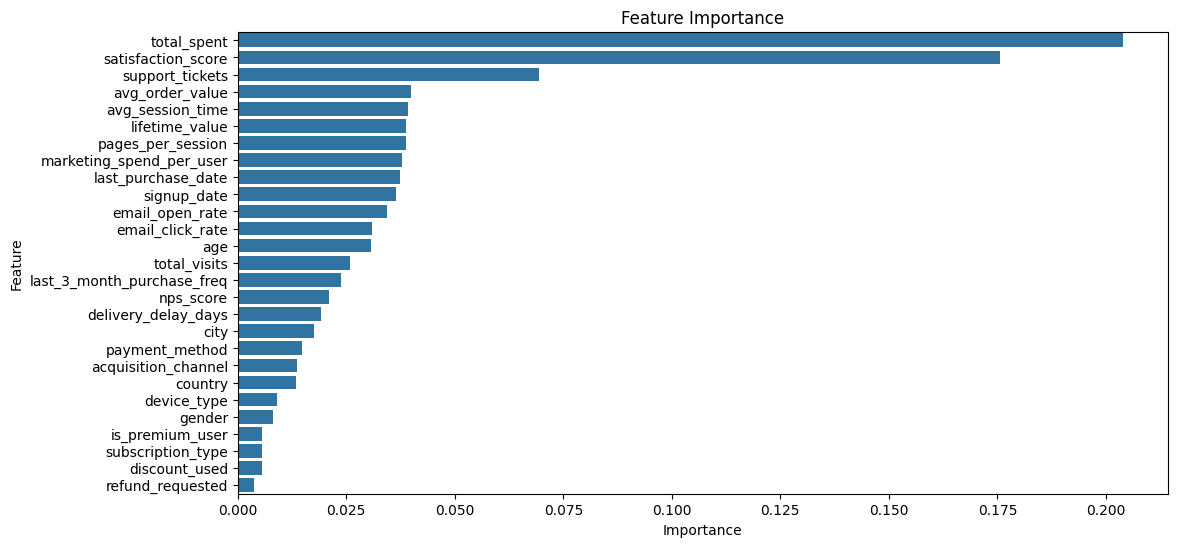

In [35]:
# =========================================================
# VISUALISASI FEATURE IMPORTANCE
# =========================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title('Feature Importance')

plt.show()


# Insight Feature Importance
- Total Spent merupakan fitur paling berpengaruh dalam memprediksi churn dengan nilai importance tertinggi.
- Satisfaction Score menjadi faktor penting kedua, menunjukkan bahwa tingkat kepuasan pelanggan sangat memengaruhi kemungkinan churn.
- Support Tickets juga memiliki pengaruh yang cukup besar, yang mengindikasikan bahwa pelanggan yang sering mengajukan keluhan cenderung memiliki risiko churn lebih tinggi.
- Fitur seperti Avg Session Time, Pages Per Session, Avg Order Value, dan Lifetime Value memberikan kontribusi sedang terhadap model.
- Sementara itu, fitur seperti Refund Requested, Discount Used, Subscription Type, dan Is Premium User memiliki pengaruh yang relatif kecil terhadap prediksi churn.

HYPERPARAMETER TUNING - LOGISTIC REGRESSION
Best Parameter : {'C': 10}
Accuracy : 0.851
Precision : 0.4906832298136646
Recall : 0.17792792792792791
F1 Score : 0.2611570247933884


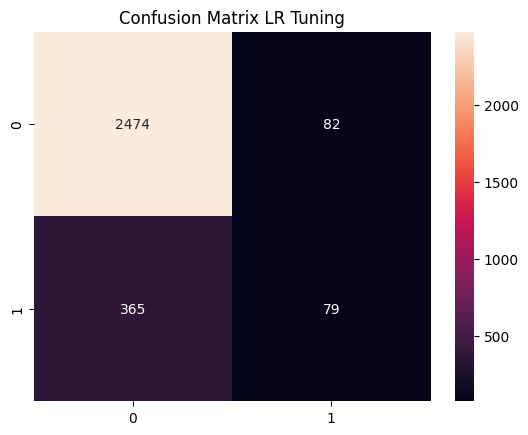

In [36]:
# =========================================================
# TUNING LOGISTIC REGRESSION
# =========================================================

param_lr = {
    'C': [0.1, 1, 10]
}

grid_lr = GridSearchCV(
    LogisticRegression(),
    param_lr,
    cv=3,
    scoring='accuracy'
)

grid_lr.fit(X_train_pre, y_train_pre)

best_lr = grid_lr.best_estimator_

y_pred_lr_tuning = best_lr.predict(X_test_pre)

print("HYPERPARAMETER TUNING - LOGISTIC REGRESSION")

print("Best Parameter :", grid_lr.best_params_)

print("Accuracy :",
      accuracy_score(y_test_pre, y_pred_lr_tuning))

print("Precision :",
      precision_score(y_test_pre, y_pred_lr_tuning))

print("Recall :",
      recall_score(y_test_pre, y_pred_lr_tuning))

print("F1 Score :",
      f1_score(y_test_pre, y_pred_lr_tuning))

cm = confusion_matrix(y_test_pre, y_pred_lr_tuning)

sns.heatmap(cm, annot=True, fmt='d')

plt.title('Confusion Matrix LR Tuning')

plt.show()

# Interpretasi
2474 data berhasil diprediksi dengan benar sebagai tidak churn (True Negative).
79 data berhasil diprediksi dengan benar sebagai churn (True Positive).
82 data diprediksi churn padahal sebenarnya tidak churn (False Positive).
365 data diprediksi tidak churn padahal sebenarnya churn (False Negative).

HYPERPARAMETER TUNING - RANDOM FOREST
Best Parameter : {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Accuracy : 0.8516666666666667
Precision : 0.49504950495049505
Recall : 0.11261261261261261
F1 Score : 0.1834862385321101


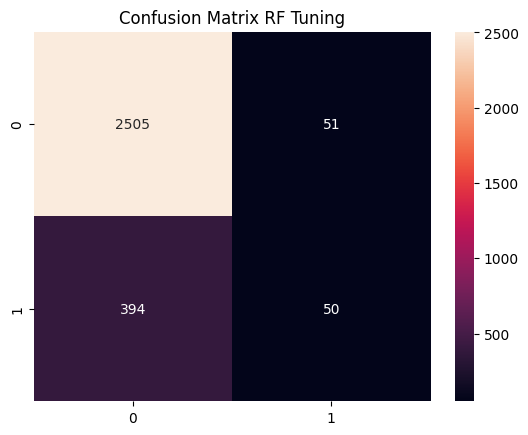

In [37]:
# =========================================================
# TUNING RANDOM FOREST
# =========================================================

param_rf = {

    'n_estimators': [100, 200],

    'max_depth': [5, 10],

    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(

    RandomForestClassifier(),

    param_rf,

    cv=3,

    scoring='accuracy'
)

grid_rf.fit(X_train_pre, y_train_pre)

best_rf = grid_rf.best_estimator_

y_pred_rf_tuning = best_rf.predict(X_test_pre)

print("HYPERPARAMETER TUNING - RANDOM FOREST")

print("Best Parameter :", grid_rf.best_params_)

print("Accuracy :",
      accuracy_score(y_test_pre, y_pred_rf_tuning))

print("Precision :",
      precision_score(y_test_pre, y_pred_rf_tuning))

print("Recall :",
      recall_score(y_test_pre, y_pred_rf_tuning))

print("F1 Score :",
      f1_score(y_test_pre, y_pred_rf_tuning))

cm = confusion_matrix(y_test_pre, y_pred_rf_tuning)

sns.heatmap(cm, annot=True, fmt='d')

plt.title('Confusion Matrix RF Tuning')

plt.show()

HYPERPARAMETER TUNING - VOTING CLASSIFIER
Accuracy : 0.8486666666666667
Precision : 0.45
Recall : 0.10135135135135136
F1 Score : 0.16544117647058823


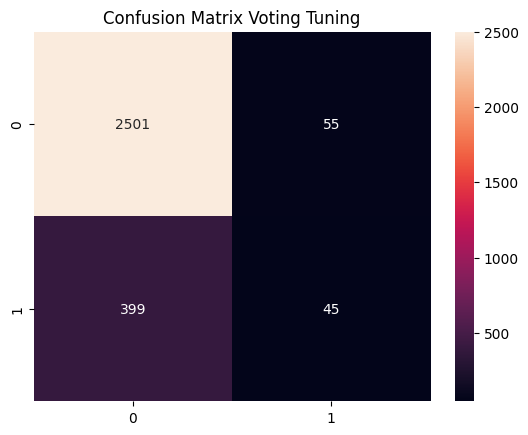

In [38]:
# =========================================================
# TUNING VOTING CLASSIFIER
# =========================================================

voting_tuning = VotingClassifier(

    estimators=[
        ('lr', LogisticRegression(C=1)),
        ('knn', KNeighborsClassifier(n_neighbors=5)),
        ('svm', SVC(probability=True))
    ],

    voting='soft'
)

voting_tuning.fit(X_train_pre, y_train_pre)

y_pred_voting_tuning = voting_tuning.predict(X_test_pre)

print("HYPERPARAMETER TUNING - VOTING CLASSIFIER")

print("Accuracy :",
      accuracy_score(y_test_pre, y_pred_voting_tuning))

print("Precision :",
      precision_score(y_test_pre, y_pred_voting_tuning))

print("Recall :",
      recall_score(y_test_pre, y_pred_voting_tuning))

print("F1 Score :",
      f1_score(y_test_pre, y_pred_voting_tuning))

cm = confusion_matrix(y_test_pre, y_pred_voting_tuning)

sns.heatmap(cm, annot=True, fmt='d')

plt.title('Confusion Matrix Voting Tuning')

plt.show()

# Interpretasi
- Nilai accuracy cukup tinggi (84.87%), yang menunjukkan bahwa sebagian besar data berhasil diprediksi dengan benar.
- Namun, recall hanya 10.36%, yang berarti model hanya mampu mendeteksi sekitar 10% pelanggan yang benar-benar churn.
- Precision 45.10% menunjukkan bahwa dari seluruh pelanggan yang diprediksi churn, sekitar 45% memang benar-benar churn.
- F1-Score 16.85% masih tergolong rendah karena model kurang mampu menyeimbangkan precision dan recall.

In [39]:
# =========================================================
# MEMILIH MODEL TERBAIK
# =========================================================

best_model = best_rf

In [40]:
# =========================================================
# SIMPAN MODEL
# =========================================================

joblib.dump(
    best_model,
    'best_model.pkl'
)

print("Model berhasil disimpan")


Model berhasil disimpan


In [41]:
# =========================================================
# DOWNLOAD MODEL
# =========================================================

from google.colab import files

files.download('best_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>